In [1]:
%pip install torch torchdiffeq scikit-learn joblib matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchdiffeq import odeint


In [3]:
ODE_PATH = r"C:\Users\Maten\Documents\projettellorosdataset\ode_data"

BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 80
HIDDEN_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


Device: cpu


In [4]:
state_cols = [
    's_x','s_y','s_z',
    's_roll','s_pitch','s_yaw',
    's_vx','s_vy','s_vz'
]

cmd_cols = ['u_ux','u_uy','u_uz','u_uyaw']

ds_cols = [
    'ds_x','ds_y','ds_z',
    'ds_roll','ds_pitch','ds_yaw',
    'ds_vx','ds_vy','ds_vz'
]

input_cols = state_cols + cmd_cols
output_cols = ds_cols


In [5]:
csv_files = glob.glob(os.path.join(ODE_PATH, "*.csv"))
if not csv_files:
    raise FileNotFoundError(f"Aucun ode.csv trouvé dans {ODE_PATH}")

dfs = []
for f in csv_files:
    df = pd.read_csv(f)

    missing = (set(input_cols + output_cols + ['dt']) - set(df.columns))
    if missing:
        raise ValueError(f"{os.path.basename(f)} colonnes manquantes: {missing}")

    df = df.fillna(df.mean(numeric_only=True))
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)
print("Dataset total :", full_df.shape)


Dataset total : (129748, 24)


In [6]:
X = full_df[input_cols].to_numpy()
Y = full_df[output_cols].to_numpy()
dt = full_df['dt'].to_numpy().reshape(-1, 1)

print("X :", X.shape)
print("Y :", Y.shape)
print("dt:", dt.shape)


X : (129748, 13)
Y : (129748, 9)
dt: (129748, 1)


In [7]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_s = scaler_X.fit_transform(X)
Y_s = scaler_Y.fit_transform(Y)

joblib.dump(scaler_X, "ode_scaler_X.pkl")
joblib.dump(scaler_Y, "ode_scaler_Y.pkl")


['ode_scaler_Y.pkl']

In [8]:
X_train, X_test, Y_train, Y_test, dt_train, dt_test = train_test_split(
    X_s, Y_s, dt,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


In [9]:
class ODEDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_ds = ODEDataset(X_train, Y_train)
test_ds  = ODEDataset(X_test, Y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


In [10]:
class ODEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, t, x):
        return self.net(x)

input_dim = len(input_cols)
output_dim = len(output_cols)

ode_func = ODEFunc(input_dim, HIDDEN_SIZE, output_dim).to(DEVICE)


In [11]:
optimizer = torch.optim.Adam(ode_func.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []

for epoch in range(1, EPOCHS + 1):
    ode_func.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        y_pred = ode_func(None, xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_ds)
    train_losses.append(epoch_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train MSE: {epoch_loss:.6e}")


Epoch 001 | Train MSE: 8.728908e-01
Epoch 005 | Train MSE: 8.316281e-01
Epoch 010 | Train MSE: 8.145967e-01
Epoch 015 | Train MSE: 7.999880e-01
Epoch 020 | Train MSE: 7.891175e-01
Epoch 025 | Train MSE: 7.794172e-01
Epoch 030 | Train MSE: 7.788568e-01
Epoch 035 | Train MSE: 7.612726e-01
Epoch 040 | Train MSE: 7.553201e-01
Epoch 045 | Train MSE: 7.434362e-01
Epoch 050 | Train MSE: 7.385393e-01
Epoch 055 | Train MSE: 7.282790e-01
Epoch 060 | Train MSE: 7.486420e-01
Epoch 065 | Train MSE: 7.166039e-01
Epoch 070 | Train MSE: 7.108971e-01
Epoch 075 | Train MSE: 7.543027e-01
Epoch 080 | Train MSE: 7.041318e-01


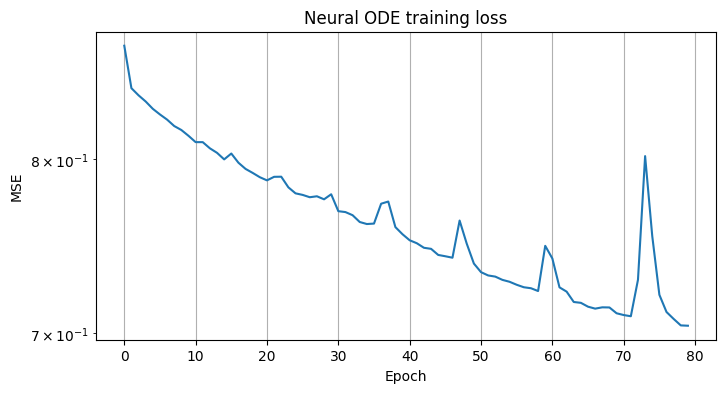

In [14]:
plt.figure(figsize=(8,4))
plt.plot(train_losses)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Neural ODE training loss")
plt.grid(True)
plt.show()


In [15]:
ode_func.eval()
preds = []
trues = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        yp = ode_func(None, xb)
        preds.append(yp.cpu().numpy())
        trues.append(yb.cpu().numpy())

preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)

preds_phys = scaler_Y.inverse_transform(preds)
trues_phys = scaler_Y.inverse_transform(trues)

rmse = np.sqrt(mean_squared_error(trues_phys, preds_phys))
print(f"RMSE global ds/dt (physique) : {rmse:.6f}")


RMSE global ds/dt (physique) : 3.250674


In [16]:
# RMSE par variable (ds/dt)
print("\nRMSE par variable (ds/dt) :")

rmse_per_var = {}
for i, name in enumerate(ds_cols):
    rmse_i = np.sqrt(mean_squared_error(trues_phys[:, i], preds_phys[:, i]))
    rmse_per_var[name] = rmse_i
    print(f"{name:10s} : {rmse_i:.6f}")


RMSE par variable (ds/dt) :
ds_x       : 0.589695
ds_y       : 0.590688
ds_z       : 0.204039
ds_roll    : 0.000286
ds_pitch   : 0.001138
ds_yaw     : 9.691097
ds_vx      : 0.455006
ds_vy      : 0.450956
ds_vz      : 0.198514


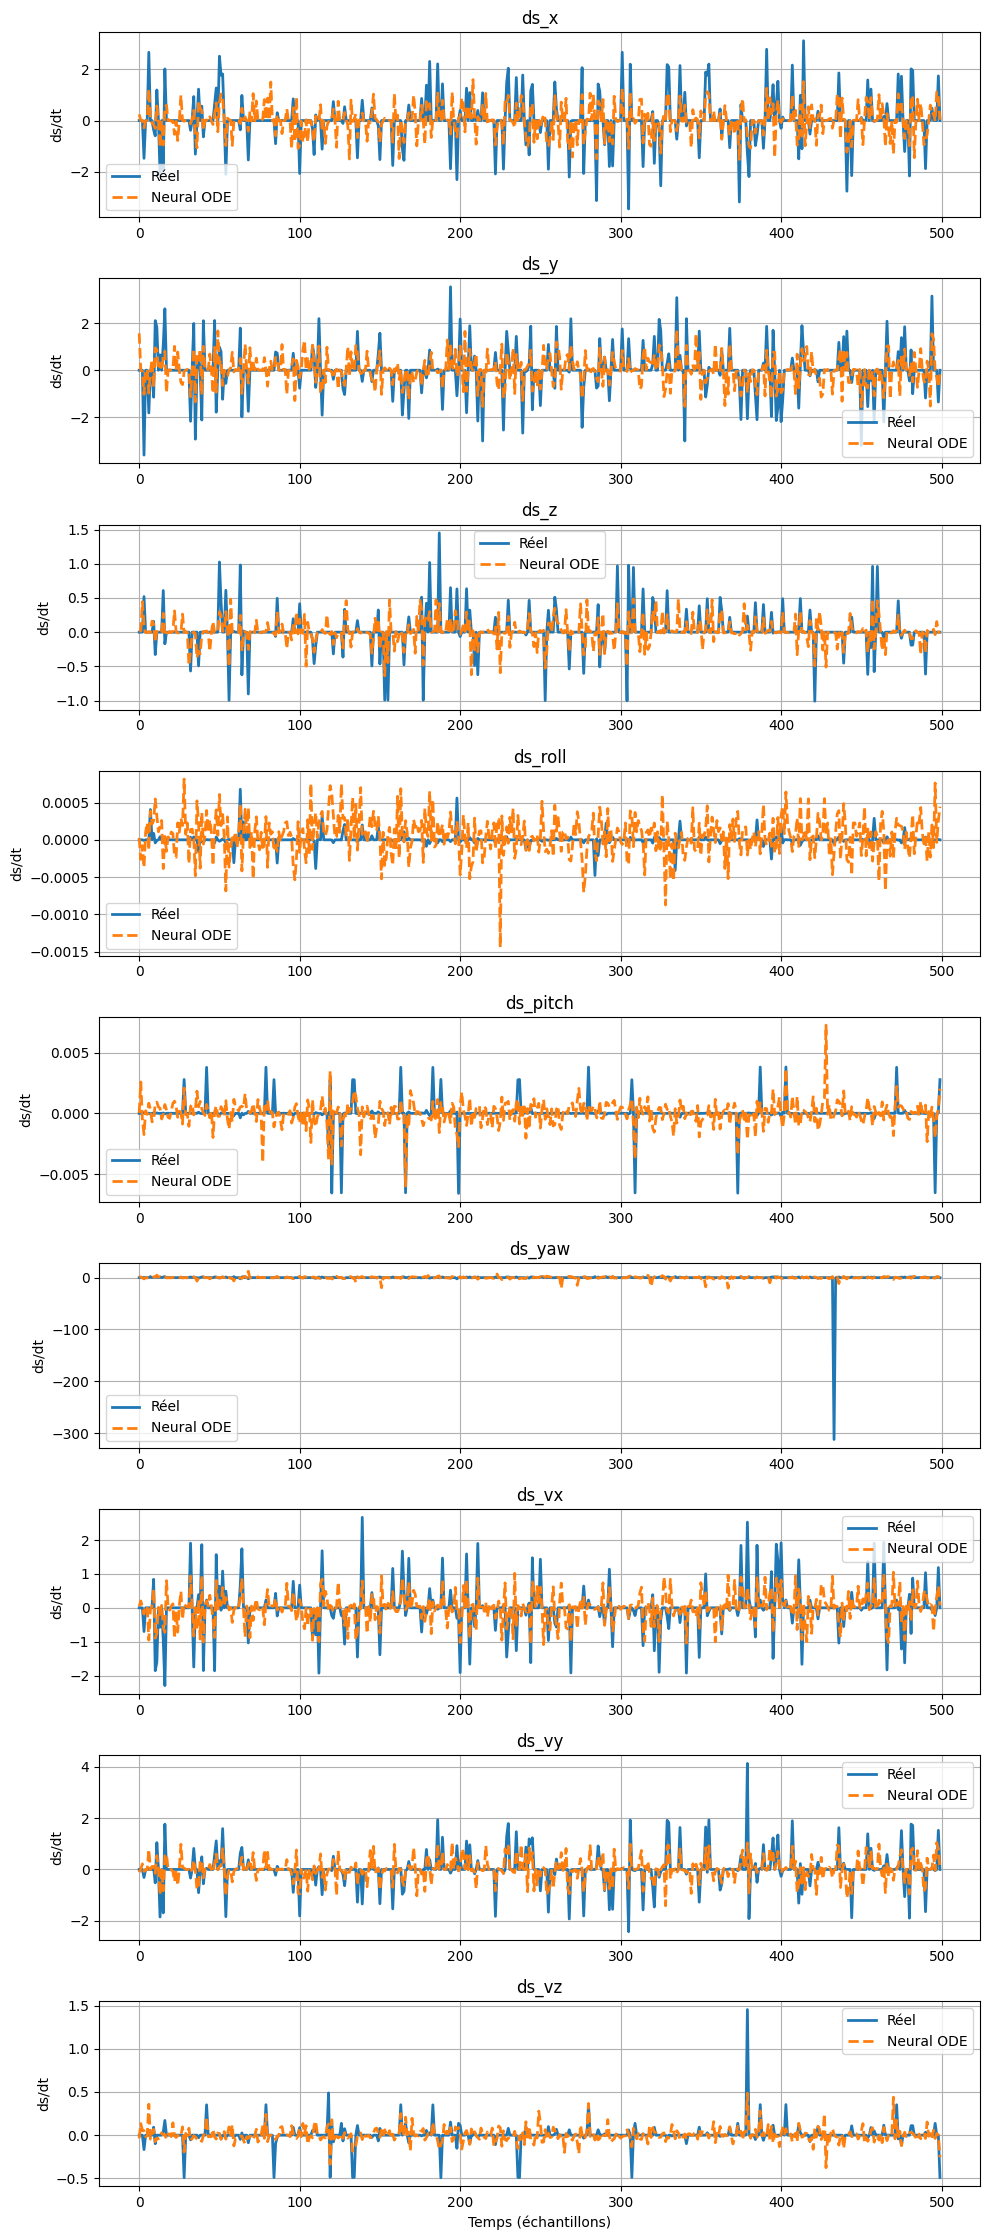

In [18]:
# Visualisation des dérivées : réel vs prédit
n_vars = preds_phys.shape[1]
n_plot = 500  # nombre de points affichés

fig, axes = plt.subplots(n_vars, 1, figsize=(10, 2.5 * n_vars))

for i in range(n_vars):
    axes[i].plot(trues_phys[:n_plot, i], label="Réel", linewidth=2)
    axes[i].plot(preds_phys[:n_plot, i], "--", label="Neural ODE", linewidth=2)
    axes[i].set_title(ds_cols[i])
    axes[i].set_ylabel("ds/dt")
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("Temps (échantillons)")
plt.tight_layout()
plt.show()


In [19]:
from sklearn.metrics import r2_score

# R² global
r2_global = r2_score(trues_phys, preds_phys)
print(f"R² global (ds/dt) : {r2_global:.4f}")

# R² par variable
print("\nR² par variable :")
r2_per_var = {}
for i, name in enumerate(ds_cols):
    r2_i = r2_score(trues_phys[:, i], preds_phys[:, i])
    r2_per_var[name] = r2_i
    print(f"{name:10s} : {r2_i:.4f}")

R² global (ds/dt) : -0.6583

R² par variable :
ds_x       : 0.4811
ds_y       : 0.4748
ds_z       : 0.4048
ds_roll    : -8.1327
ds_pitch   : -0.1875
ds_yaw     : 0.0049
ds_vx      : 0.4480
ds_vy      : 0.4489
ds_vz      : 0.1334


In [20]:
# Précision relative (%) sur ds/dt
num = np.linalg.norm(trues_phys - preds_phys)
den = np.linalg.norm(trues_phys)

relative_accuracy = 100 * (1 - num / den)
print(f"Précision relative globale (ds/dt) : {relative_accuracy:.2f} %")

Précision relative globale (ds/dt) : 0.77 %


In [21]:
OUT_DIR = "./trained_neural_ode"
os.makedirs(OUT_DIR, exist_ok=True)

torch.save(ode_func.state_dict(), os.path.join(OUT_DIR, "neural_ode.pth"))
joblib.dump(scaler_X, os.path.join(OUT_DIR, "scaler_X.pkl"))
joblib.dump(scaler_Y, os.path.join(OUT_DIR, "scaler_Y.pkl"))

print("Neural ODE sauvegardé dans", os.path.abspath(OUT_DIR))


Neural ODE sauvegardé dans C:\Users\Maten\trained_neural_ode
